In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import pickle

import fns_NN
import fns_plotting_scripts as fns_plot

# Load data
cond = 'B50'
file_suffix = '.png'

directory = '/Users/idse/data_tmp/signaldecoding/data_expt_20_scaled_norm_bgsub'
subdirectory_data = directory + '/data'
subdirectory_plot_fig = directory + '/fig2'

f = open(subdirectory_data + '/data_' + cond + ".pickle", 'rb')
data = pickle.load(f)
f.close()

# Use signals as input
feature = data.signals[:, :, :]
target = data.genes[:, :, :]

train_size = 3
(feat_train, feat_test, tar_train, tar_test, 
         metricdist_train, metricdist_test, markers_train, markers_test) = fns_NN.test_train_split_colonies(
            data, feature, target, train_size=train_size
        )


MI = np.zeros((data.N_signals, data.N_signals))

for si in range(data.N_signals):
    for sj in range(si+1, data.N_signals):
        MI[si,sj] = fns_plot.calc_MI_sklearn(feat_test[:, si], feat_test[:, sj])
        MI[sj,si] = MI[si,sj]

In [61]:
with open(subdirectory_plot_fig + 'MI.pkl', 'rb') as f:
    MI_total, MI_individual, MI_individualandsmad, MI_leaveoneout = pickle.load(f)

MI_individual_mean = np.mean(MI_individual,axis=0)

<Axes: >

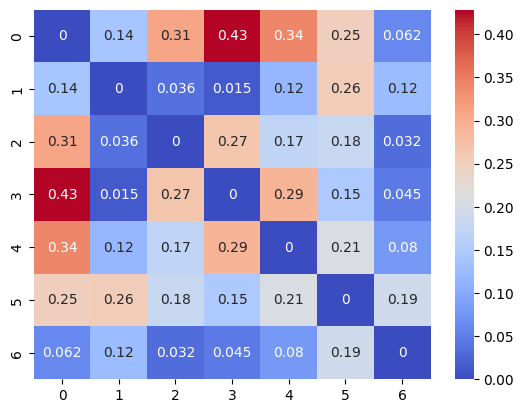

In [47]:
import seaborn as sns
sns.heatmap(MI, annot=True, cmap='coolwarm')

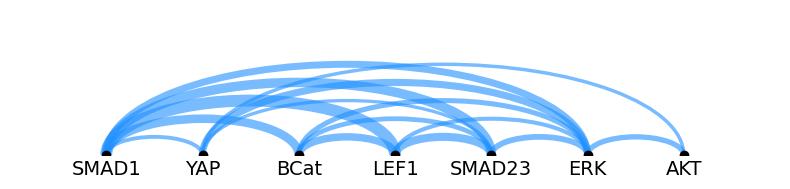

In [53]:
corr = MI;
labels = data.signal_names
n = len(labels)

fig, ax = plt.subplots(figsize=(8,2))
ax.set_xlim(-1, n)
ax.set_ylim(0, 2)
ax.axis('off')

# Draw nodes along x-axis
x_pos = np.arange(n)
for i, label in enumerate(labels):
    ax.text(x_pos[i], -0.2, label, ha='center', va='center', fontsize=14, color='black')
    ax.plot(x_pos[i], 0, 'o', color='k', markersize=6)

# Draw arches for off-diagonal correlations
for i in range(n):
    for j in range(i+1, n):
        strength = abs(corr[i,j])
        if strength < 0.1:  # threshold to skip weak correlations
            continue
        mid = (x_pos[i] + x_pos[j])/2
        width = abs(x_pos[j] - x_pos[i])
        height = width/2
        color = 'dodgerblue' if corr[i,j] > 0 else 'salmon'
        linewidth = 20*strength  # thickness encodes strength
        arc = Arc((mid, 0), width=width, height=height, angle=0, theta1=0, theta2=180,
                  color=color, linewidth=linewidth, alpha=0.6)
        ax.add_patch(arc)

plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'MI' + '_sig2sig' + cond + file_suffix)

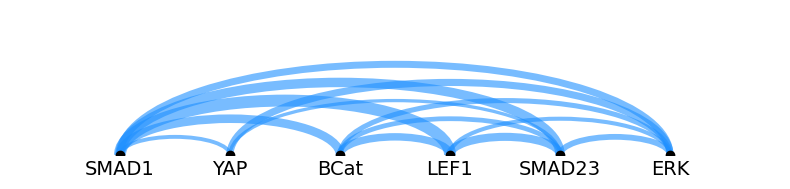

In [57]:
corr = MI[:-1,:-1];
labels = data.signal_names[:-1]
n = len(labels)

fig, ax = plt.subplots(figsize=(8,2))
ax.set_xlim(-1, n)
ax.set_ylim(0, 2)
ax.axis('off')

# Draw nodes along x-axis
x_pos = np.arange(n)
for i, label in enumerate(labels):
    ax.text(x_pos[i], -0.2, label, ha='center', va='center', fontsize=14, color='black')
    ax.plot(x_pos[i], 0, 'o', color='k', markersize=6)

# Draw arches for off-diagonal correlations
for i in range(n):
    for j in range(i+1, n):
        strength = abs(corr[i,j])
        if strength < 0.1:  # threshold to skip weak correlations
            continue
        mid = (x_pos[i] + x_pos[j])/2
        width = abs(x_pos[j] - x_pos[i])
        height = width/2
        color = 'dodgerblue' if corr[i,j] > 0 else 'salmon'
        linewidth = 20*strength  # thickness encodes strength
        arc = Arc((mid, 0), width=width, height=height, angle=0, theta1=0, theta2=180,
                  color=color, linewidth=linewidth, alpha=0.6)
        ax.add_patch(arc)

plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'MI' + '_sig2sig_noAKT_' + cond + file_suffix)

In [29]:
import pandas as pd
sigs = pd.DataFrame(feat_test, columns=data.signal_names)

In [30]:
sigs.corr()

,SMAD1,YAP,BCat,LEF1,SMAD23,ERK,AKT
SMAD1,1.000000,0.451920,0.514086,0.480054,0.578203,-0.140035,-0.166174
YAP,0.451920,1.000000,0.141097,-0.040527,0.417440,-0.502230,-0.361324
BCat,0.514086,0.141097,1.000000,0.444957,0.360250,0.218329,0.151932
LEF1,0.480054,-0.040527,0.444957,1.000000,0.354735,0.300573,0.100613
SMAD23,0.578203,0.417440,0.360250,0.354735,1.000000,-0.051550,-0.286838
ERK,-0.140035,-0.502230,0.218329,0.300573,-0.051550,1.000000,0.391375
AKT,-0.166174,-0.361324,0.151932,0.100613,-0.286838,0.391375,1.000000


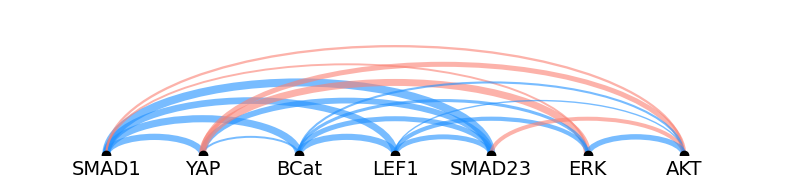

In [54]:
sigs = pd.DataFrame(feat_test, columns=data.signal_names);
corr = sigs.corr().to_numpy()
labels = data.signal_names
n = len(labels)

fig, ax = plt.subplots(figsize=(8,2))
ax.set_xlim(-1, n)
ax.set_ylim(0, 2)
ax.axis('off')

# Draw nodes along x-axis
x_pos = np.arange(n)
for i, label in enumerate(labels):
    ax.text(x_pos[i], -0.2, label, ha='center', va='center', fontsize=14, color='black')
    ax.plot(x_pos[i], 0, 'o', color='k', markersize=6)

# Draw arches for off-diagonal correlations
for i in range(n):
    for j in range(i+1, n):
        strength = abs(corr[i,j])
        if strength < 0.1:  # threshold to skip weak correlations
            continue
        mid = (x_pos[i] + x_pos[j])/2
        width = abs(x_pos[j] - x_pos[i])
        height = width/2
        color = 'dodgerblue' if corr[i,j] > 0 else 'salmon'
        linewidth = 10*strength  # thickness encodes strength
        arc = Arc((mid, 0), width=width, height=height, angle=0, theta1=0, theta2=180,
                  color=color, linewidth=linewidth, alpha=0.6)
        ax.add_patch(arc)

plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'corr' + '_sig2sig' + cond + file_suffix)

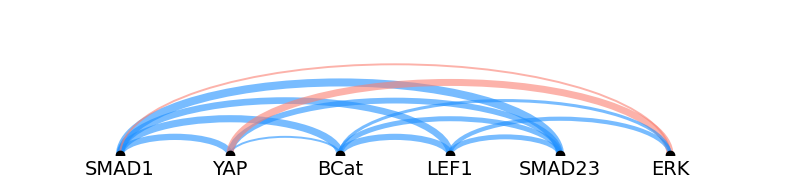

In [56]:
sigs = pd.DataFrame(feat_test, columns=data.signal_names);
corr = sigs.corr().to_numpy()
corr = corr[:-1,:-1]
labels = data.signal_names[:-1]
n = len(labels)

fig, ax = plt.subplots(figsize=(8,2))
ax.set_xlim(-1, n)
ax.set_ylim(0, 2)
ax.axis('off')

# Draw nodes along x-axis
x_pos = np.arange(n)
for i, label in enumerate(labels):
    ax.text(x_pos[i], -0.2, label, ha='center', va='center', fontsize=14, color='black')
    ax.plot(x_pos[i], 0, 'o', color='k', markersize=6)

# Draw arches for off-diagonal correlations
for i in range(n):
    for j in range(i+1, n):
        strength = abs(corr[i,j])
        if strength < 0.1:  # threshold to skip weak correlations
            continue
        mid = (x_pos[i] + x_pos[j])/2
        width = abs(x_pos[j] - x_pos[i])
        height = width/2
        color = 'dodgerblue' if corr[i,j] > 0 else 'salmon'
        linewidth = 10*strength  # thickness encodes strength
        arc = Arc((mid, 0), width=width, height=height, angle=0, theta1=0, theta2=180,
                  color=color, linewidth=linewidth, alpha=0.6)
        ax.add_patch(arc)

plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'corr' + '_sig2sig_noAKT_' + cond + file_suffix)

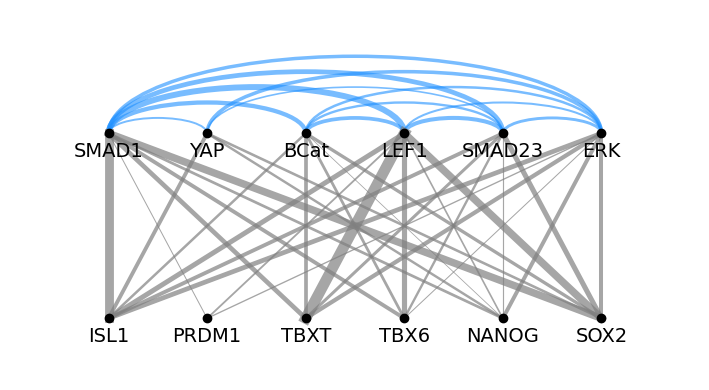

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

# Example data
# n = 5  # top layer nodes
# m = 3  # bottom layer nodes
# corr = np.random.uniform(-1, 1, (n, n)) # example 'correlation' matrix for arches, use your MI
# labels_top = [f"Top {i+1}" for i in range(n)]

# conn = np.random.uniform(0, 1, (n, m))  # n-by-m connection strengths matrix
# labels_bottom = [f"Bottom {i+1}" for i in range(m)]

sigs = pd.DataFrame(feat_test, columns=data.signal_names)
corr = sigs.corr().to_numpy()
corr = corr[:-1, :-1]
labels_top = data.signal_names[:-1]
n = len(labels)

corr = MI[:-1,:-1];
labels_top = data.signal_names[:-1]
n = len(labels)

labels_bottom = [data.gene_names[i] for i in [0,6,9,11,13,14]]
conn = MI_individual_mean.T
conn = conn[:-1,np.array([0,6,9,11,13,14])];
m = len(labels_bottom) 

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(max(n, m)*1.2, 4))
ax.set_xlim(-1, max(n, m))
ax.set_ylim(-4, 2)
ax.axis('off')

x_pos_top = np.linspace(0, max(n, m)-1, n)
x_pos_bot = np.linspace(0, max(n, m)-1, m)
y_top = 0
y_bot = -3

# Draw top-layer nodes
for i, label in enumerate(labels_top):
    ax.text(x_pos_top[i], y_top-0.3, label, ha='center', va='center', fontsize=14, color='k')
    ax.plot(x_pos_top[i], y_top, 'o', color='k', markersize=6)

# Draw bottom-layer nodes
for j, label in enumerate(labels_bottom):
    ax.text(x_pos_bot[j], y_bot-0.3, label, ha='center', va='center', fontsize=14, color='k')
    ax.plot(x_pos_bot[j], y_bot, 'o', color='k', markersize=6)

sc = 10

# Draw arches for off-diagonal correlations (top layer)
for i in range(n):
    for j in range(i+1, n):
        strength = abs(corr[i, j])
        if strength < 0.1:
            continue
        mid = (x_pos_top[i] + x_pos_top[j]) / 2
        width = abs(x_pos_top[j] - x_pos_top[i])
        height = width / 2
        color = 'dodgerblue' if corr[i, j] > 0 else 'salmon'
        linewidth = sc * strength
        arc = Arc((mid, y_top), width=width, height=height, angle=0, theta1=0, theta2=180,
                  color=color, linewidth=linewidth, alpha=0.6)
        ax.add_patch(arc)

# Draw lines between top and bottom layers, with thickness from conn
for i in range(n):
    for j in range(m):
        strength = conn[i, j]
        if strength < 0.05:  # skip very weak
            continue
        linewidth = sc * strength
        ax.plot([x_pos_top[i], x_pos_bot[j]], [y_top, y_bot],
                color='grey', lw=linewidth, alpha=0.7, zorder=1)

plt.tight_layout()
plt.savefig(subdirectory_plot_fig + "/" + 'corr' + '_sig2sig_and_sig2fate' + cond + file_suffix)